In [ ]:
# pip installs
!pip install livelossplot

# Standard library imports
import os
import io
import sys
import itertools

# Third-party imports
import numpy as np
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
from tqdm import tqdm
from livelossplot import PlotLosses
from huggingface_hub import hf_hub_download
from scipy.sparse import coo_matrix
from sklearn.model_selection import train_test_split


# PyTorch imports
import torch
from torch import nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split
import torchvision
from torchvision.utils import make_grid
from torchvision import models
from torchsummary import summary
from torchsummary import summary
import torch.optim as optim

In [ ]:
# Mount drive
from google.colab import drive, runtime
drive.mount('/content/drive')

# Get device
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
    device = 'cpu'

# Function to fix random seed
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled   = True

    return True

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cuda installed! Running on GPU!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.h5:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

events.csv:   0%|          | 0.00/782k [00:00<?, ?B/s]

'data/events.csv'

In [ ]:
# this function loads all of the image arrays for a given id
def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

event = load_event("S778114")
for img_type in event:
    print(f"{img_type}: {event[img_type].shape} ({event[img_type].dtype})")


vis: (384, 384, 36) (int16)
ir069: (192, 192, 36) (int16)
ir107: (192, 192, 36) (int16)
vil: (384, 384, 36) (uint8)
lght: (38777, 5) (float32)


In [ ]:
def load_ids(file_name="data/events.csv", frac=0.01):
    "Load ids"
    df = pd.read_csv(file_name)
    ids = df.id.unique()
    ids = np.random.choice(ids, size=int(frac*len(ids)), replace=False)
    return ids

def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

def down_sample(img, to_size):
    """
    Downsample image.

    :param img: Input image of shape [H, W, D] where D is the number of frames.
    :param to_size: Target size for downsampling (e.g., 64 for 64x64).
    :return: Downsampled image of shape [to_size, to_size, D].
    """
    if img.ndim != 3:
        raise ValueError("Input image must have 3 dimensions [H, W, D]")

    img = torch.tensor(img, dtype=torch.float32)
    # Permute to shape [D, H, W] for processing
    img = img.permute(2, 0, 1).unsqueeze(1)  # Shape: [D, 1, H, W]
    downsampled_img = torch.nn.functional.interpolate(img, size=(to_size, to_size), mode='bilinear', align_corners=False)
    # Squeeze and permute back to shape [to_size, to_size, D]
    downsampled_img = downsampled_img.squeeze(1).permute(1, 2, 0).numpy()
    return downsampled_img


def normalise_sample(img):
    """
    Normalise image to [0, 1] range.
    """
    img = img - np.min(img)
    img = img / np.max(img)
    return img


def get_targets(event):
    """
    Maps lightning strikes of an event into a sparse target mask.
    Returned targets represent lightning strikes map for each frame (36) of the event.

    :rtype: list of sparse matrices of shape (384, 384) for each frame
    """
    t = event["lght"][:,0]
    target = np.zeros((384, 384, 36))

    # For each frame in the event
    for ti in range(36):
        # Find which lightning strikes fall in current frame and store their coodinates
        f = (t >= ti*5*60) & (t < ti*5*60 + 5*60)
        xs = event["lght"][f,3]
        ys = event["lght"][f,4]

        # Set the coordinates to 1 in the target tensor
        for x, y in zip(xs, ys):
            target[int(x), int(y), ti] += 1

    return target

In [ ]:
class LightningDataset(Dataset):
    def __init__(self, ids, target_max=100):
        self.target_max = target_max
        self.events = [load_event(id) for id in ids]

        # Downsample and normalise images
        for event in self.events:
            event["vis"] = down_sample(event["vis"], to_size=64)
            event["vis"] = normalise_sample(event["vis"])
            event["vil"] = down_sample(event["vil"], to_size=64)
            event["vil"] = normalise_sample(event["vil"])
            event["ir069"] = down_sample(event["ir069"], to_size=64)
            event["ir069"] = normalise_sample(event["ir069"])
            event["ir107"] = down_sample(event["ir107"], to_size=64)

    def __len__(self):
        "Returns total number of samples"
        return len(self.events)

    def __getitem__(self, idx):
        "Returns a single sample from the dataset"
        # Load event from id
        event = self.events[idx]
        # Get the targets and normalise
        target = get_targets(event)
        target = target / self.target_max

        # Convert to PyTorch tensors and stack the image types into a single tensor
        vis = torch.tensor(event["vis"], dtype=torch.float32)
        vil = torch.tensor(event["vil"], dtype=torch.float32)
        ir069 = torch.tensor(event["ir069"], dtype=torch.float32)
        ir107 = torch.tensor(event["ir107"], dtype=torch.float32)

        # Stack the inputs to form a single tensor of shape (36, 4, 64, 64)
        X = torch.stack([vis, ir069, ir107, vil], dim=0).permute(3, 0, 1, 2).reshape( 36*4, 64, 64)
        # Convert dense_targets to PyTorch tensor and ensure shape is (1, 36, 384, 384)
        Y = torch.tensor(target, dtype=torch.float32).permute(2, 0, 1)

        return X, Y

In [ ]:
"""
Creating DataLoaders.

"""

# Load IDs and split into train and test sets
ids = load_ids(frac=0.05)
train_ids, test_ids = train_test_split(ids, test_size=0.2)

# Print the number of events
print(f"Number of training events: {len(train_ids)}")
print(f"Number of testing events: {len(test_ids)}")

# Initialize the dataset and dataloader
train_dataset = LightningDataset(train_ids)
train_dataloader = DataLoader(train_dataset, batch_size=6, shuffle=True)

val_dataset = LightningDataset(test_ids)
val_dataloader = DataLoader(val_dataset, batch_size=6, shuffle=True)


# Test the DataLoader
for X, y in train_dataloader:
    print("Training batch shapes:")
    print(X.shape)  # Should be (6, 36, 4, 64, 64)
    print(y.shape)  # Should be (6, 36, 1, 384, 384)
    break

for X, y in val_dataloader:
    print("Validation batch shapes:")
    print(X.shape)  # Should be (6, 36, 4, 64, 64)
    print(y.shape)  # Should be (6, 36, 1, 384, 384)
    break


Number of training events: 32
Number of testing events: 8
Training batch shapes:
torch.Size([6, 144, 64, 64])
torch.Size([6, 36, 384, 384])
Validation batch shapes:
torch.Size([6, 144, 64, 64])
torch.Size([6, 36, 384, 384])


In [ ]:
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])
ids = df.id.unique()
id = ids[0]


dataset = LightningDataset([id])
print(len(dataset))
print(dataset[0][0].shape)
print(dataset[0][1].shape)

1
torch.Size([144, 64, 64])
torch.Size([36, 384, 384])


In [ ]:
class UNet(nn.Module):
    def __init__(self, input_channels=36*4, output_channels=36):
        super(UNet, self).__init__()

        # Encoding path
        self.enc_conv1 = nn.Conv2d(input_channels, 128, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc_conv2 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec_conv1 = nn.Conv2d(512, 256,kernel_size=3, padding=1)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec_conv2 = nn.Conv2d(256, 128, kernel_size=3, padding=1)

        self.up3 = nn.ConvTranspose2d(128, 128, kernel_size=6, stride=6)
        self.dec_conv3 = nn.Conv2d(128, 64, kernel_size=3, padding=1)

        # Output layer
        self.output_layer = nn.Conv2d(64, output_channels, kernel_size=1)  # Linear activation (no ReLU)

    def forward(self, x):
        # Encoding path
        enc1 = torch.relu(self.enc_conv1(x))
        pool1 = self.pool1(enc1)

        enc2 = torch.relu(self.enc_conv2(pool1))
        pool2 = self.pool2(enc2)

        # Bottleneck
        bottleneck = torch.relu(self.bottleneck(pool2))

        # Decoding path using transposed convolutions
        up1 = self.up1(bottleneck)
        concat1 = torch.cat([up1, enc2], dim=1)
        dec1 = torch.relu(self.dec_conv1(concat1))

        up2 = self.up2(dec1)
        concat2 = torch.cat([up2, enc1], dim=1)
        dec2 = torch.relu(self.dec_conv2(concat2))

        up3 = self.up3(dec2)
        dec3 = torch.relu(self.dec_conv3(up3))

        # Output layer (applied sigmoid to ensure output is between 0 and 1)
        outputs = torch.sigmoid(self.output_layer(dec3))
        return outputs

In [ ]:
model = UNet()

# Example input tensor
batch_size = 2
temporal_frames = 36
features_per_frame = 4  # Assuming 4 features per frame
height, width = 64, 64

# Creating input in (batch, channels, height, width) format
example_input = torch.randn(batch_size, temporal_frames * features_per_frame, height, width)

# Forward pass
output = model(example_input)
print("Output shape:", output.shape)  # Expected: (1, 36, 384, 384)

Output shape: torch.Size([2, 36, 384, 384])


In [ ]:
from torchvision import models
from torchsummary import summary
from torchsummary import summary


input_channels = 12
output_channels = 12
model = UNet(input_channels=input_channels, output_channels=output_channels)
summary(model, input_size=(12, 384, 384), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1        [-1, 128, 384, 384]          13,952
         MaxPool2d-2        [-1, 128, 192, 192]               0
            Conv2d-3        [-1, 256, 192, 192]         295,168
         MaxPool2d-4          [-1, 256, 96, 96]               0
            Conv2d-5          [-1, 512, 96, 96]       1,180,160
   ConvTranspose2d-6        [-1, 256, 192, 192]         524,544
            Conv2d-7        [-1, 256, 192, 192]       1,179,904
   ConvTranspose2d-8        [-1, 128, 384, 384]         131,200
            Conv2d-9        [-1, 128, 384, 384]         295,040
  ConvTranspose2d-10      [-1, 128, 2304, 2304]         589,952
           Conv2d-11       [-1, 64, 2304, 2304]          73,792
           Conv2d-12       [-1, 12, 2304, 2304]             780
Total params: 4,284,492
Trainable params: 4,284,492
Non-trainable params: 0
---------------------------

In [ ]:

from torch.utils.data import DataLoader
import random

batch_size = 10

# Load IDs and split into train and test sets
ids = load_ids(frac=0.1)
train_ids, val_ids = train_test_split(ids, test_size=0.8)

# Initialize the dataset
train_dataset = LightningDataset(train_ids, target_max=100)
val_dataset = LightningDataset(val_ids, target_max=100)

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


max normalised lightining in frame 1:  tensor(0.0100)


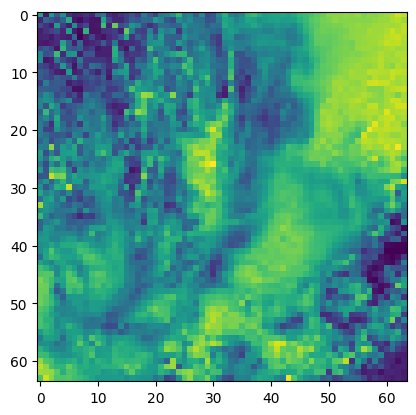

In [ ]:
# Get validation sample
input_sample, target_sample = next(iter(val_loader))
input_sample.shape

sample_image = input_sample[0,0,:,:].reshape(64,64)
plt.imshow(sample_image)
print("max normalised lightining in frame 1: ", torch.max(target_sample[0][0]))

In [ ]:
# Custom Total Absolute Error Loss
class TotalAbsoluteError(nn.Module):
    def __init__(self):
        super(TotalAbsoluteError, self).__init__()

    def forward(self, input, target):
        # Compute the absolute error
        absolute_error = torch.abs(input - target)
        # Sum up all the absolute errors
        total_absolute_error = absolute_error.sum()
        return total_absolute_error

In [ ]:
import torch.optim as optim

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the U-Net model and move it to the selected device
model = UNet().to(device)

# Define the loss function and optimizer
criterion = TotalAbsoluteError()  # Mean squared error for regression tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Store loss values for plotting
train_losses = []
val_losses = []

# Training loop with loss tracking
num_epochs = 10

for epoch in range(num_epochs):
    print(f"Epoch:{epoch}")
    model.train()
    running_loss = 0.0
    for input, target in train_loader:
        input, target = input.to(device), target.to(device)
        # Forward pass
        optimizer.zero_grad()
        output = model(input)
        # Calculate loss
        loss = criterion(output, target)
        running_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    # Calculate training loss
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss}")

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for input, target in val_loader:
            input, target = input.to(device), target.to(device)

            # Forward pass
            output = model(input)
            loss = criterion(output, target)
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss}")

Using device: cuda
Epoch:0
Epoch [1/10], Training Loss: 16465625.5
Validation Loss: 8953345.57142857
Epoch:1
Epoch [2/10], Training Loss: 7234448.0
Validation Loss: 5465607.357142857
Epoch:2
Epoch [3/10], Training Loss: 4478972.0
Validation Loss: 3715972.25
Epoch:3
Epoch [4/10], Training Loss: 2989476.3125
Validation Loss: 2239361.8125
Epoch:4
Epoch [5/10], Training Loss: 1874407.9375
Validation Loss: 1778652.2589285714
Epoch:5
Epoch [6/10], Training Loss: 1502314.625
Validation Loss: 1460453.1964285714
Epoch:6
Epoch [7/10], Training Loss: 1245926.46875
Validation Loss: 1362740.5535714286
Epoch:7
Epoch [8/10], Training Loss: 1177897.125
Validation Loss: 1311123.0
Epoch:8
Epoch [9/10], Training Loss: 1142694.65625
Validation Loss: 1256409.0982142857
Epoch:9
Epoch [10/10], Training Loss: 1095616.34375
Validation Loss: 1246066.9464285714


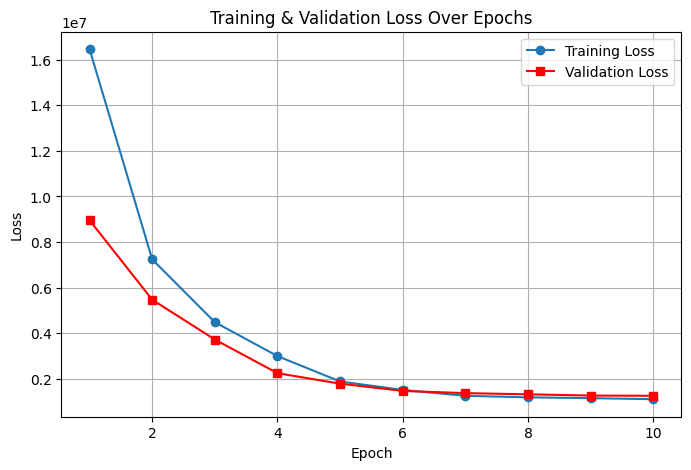

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', linestyle='-', color='red', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

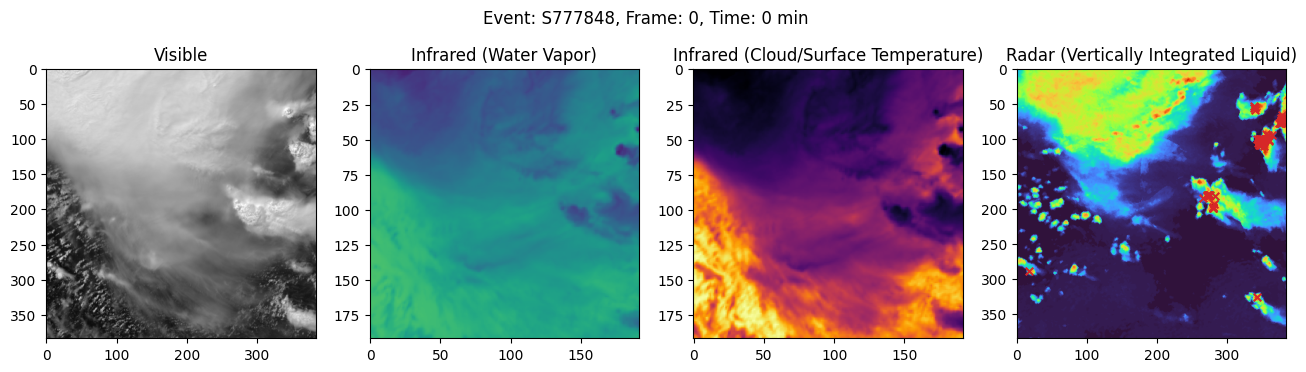

In [ ]:
"""
Predicting Events using the trained model.
"""

import matplotlib.pyplot as plt
import os
import IPython.display


def plot_event(id, frame=0):
    """Helper function for plotting an event"""
    event = load_event(id)
    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        fig,axs = plt.subplots(1,4,figsize=(16,4))
        fig.suptitle(f"Event: {id}, Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar (Vertically Integrated Liquid)')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)
        plt.show()

    plot_frame(frame)

# Example usage
plot_event(id=ids[0], frame=0)

Validation batch shapes:
torch.Size([7, 144, 64, 64])
torch.Size([7, 36, 384, 384])
torch.Size([7, 144, 64, 64]) torch.Size([7, 36, 384, 384])

PREDICTION INFORMATION
sum:  tensor(136192.)
max:  tensor(1.)
mean:  tensor(0.0257)

TARGET INFORMATION
sum:  1793.0
max:  28.0
mean:  0.0003377655406057099

MSE CALCULATION
mse:  tensor(0.0265, dtype=torch.float64)
l1 loss:  tensor(0.0260, dtype=torch.float64)
cross entropy loss:  tensor(-0., dtype=torch.float64)


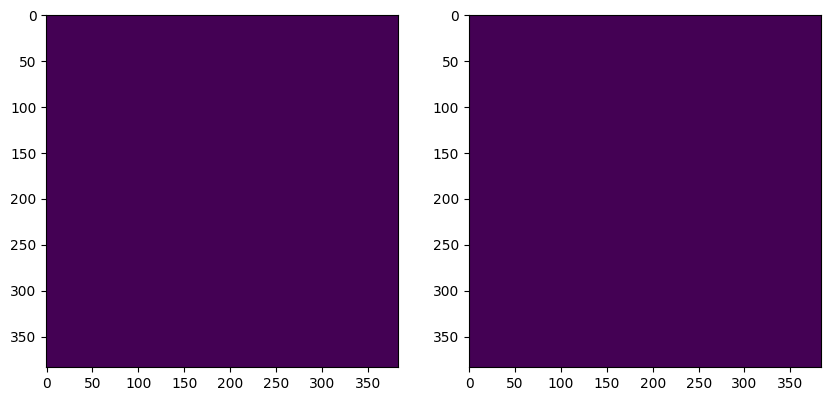

In [ ]:
def plot_event(id, frame=0):
    """Helper function for plotting an event"""
    event = load_event(id)
    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        fig,axs = plt.subplots(1,4,figsize=(16,4))
        fig.suptitle(f"Event: {id}, Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar (Vertically Integrated Liquid)')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)
        plt.show()

    plot_frame(frame)



# event id to plot
index = 3
m_id = ids[index]

m_event = load_event(m_id)
event_targets = get_targets(m_event)

predict_events = [ids[idx] for idx in range(index, batch_size)]
predict_dataset = LightningDataset(predict_events, target_max=100)
predict_loader = DataLoader(predict_dataset, batch_size=batch_size, shuffle=True)

for X, y in predict_loader:
    print("Validation batch shapes:")
    print(X.shape)  # Should be (10, 36, 4, 64, 64)
    print(y.shape)  # Should be (10, 36, 1, 384, 384)
    break



for X_next, y_next in predict_loader:
  print(X_next.shape, y_next.shape)
  prediction_batch = model(X_next.to(device)).detach().cpu()


# prediction information
print("\nPREDICTION INFORMATION")
event1_pred_norm = prediction_batch[0]
event1_pred = event1_pred_norm * 100# target_max: 100
event1_pred = event1_pred_norm * 1
print("sum: ", torch.sum(event1_pred))
print("max: ", torch.max(event1_pred))
print("mean: ", torch.mean(event1_pred))


# target information
print("\nTARGET INFORMATION")
print("sum: ", np.sum(event_targets))
print("max: ", np.max(event_targets))
print("mean: ", np.mean(event_targets))


print("\nMSE CALCULATION")
tensor_label = torch.tensor(event_targets).reshape(36, 384, 384)
loss = torch.nn.functional.mse_loss(tensor_label, event1_pred)
print("mse: ", loss)
l1_loss = torch.nn.functional.l1_loss(tensor_label, event1_pred)
print("l1 loss: ", l1_loss)
cross_entropy = torch.nn.functional.cross_entropy(tensor_label[0], event1_pred[0])
print("cross entropy loss: ", cross_entropy)


# plotting label and target
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(tensor_label[0])
axs[1].imshow(event1_pred[0])
plt.show()



# print("\nCOMPARINS SMALL SECTIONS OF THE PREDICTION AND LABEL")
# for i in range(36):
#   loss = torch.nn.functional.mse_loss(event1_pred[i], tensor_label[i])
#   if (loss != 0):
#     print("i: ", i)
#     print(loss)